In [11]:
import pandas as pd
import numpy as np
from datetime import datetime
from tqdm import tqdm

In [12]:
df = pd.read_excel('fin_data_of_proj.xlsx')

In [13]:
# target_zero_df = df[df['Target'] == 0]

# rows_to_drop = target_zero_df.sample(frac=0.2, random_state=1).index

# df = df.drop(rows_to_drop)

## Feature Engeniring and data cleaning

In [14]:
# Unfin_cost and Season of every year

def get_season(date):
    month = date.month if pd.notnull(date) else None
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return None

df['season'] = df['dpg_date'].apply(get_season)
df['unfin_coff'] = df['unfin_cost']/df['cost_plan']

In [15]:
# Inflaction of every year 8%
annual_inflation_rate = 0.08
inflation_reference_date = datetime(2024, 11, 1)


df['dpg_date'] = pd.to_datetime(df['dpg_date'], errors='coerce')

financial_columns = [
    'cost_plan', 'flat_msprice', 'build_mscost', 'flat_mscost', 'com_msprice', 'park_price',
    'self_cost', 'unfin_cost', 'share_cost', 'warr_cost', 'comm_cost', 'cost_official',
    'Итого краткосрочные активы', 'Итого краткосрочных обязательств', 'Денежные средства',
    'Краткосрочная дебиторская задолженность', 'Запасы', 'Себестоимость', 'Доход от реализации',
    'Итого активы', 'Итого капитал', 'Итого пассивы', 'Краткосрочная кредиторская задолженность',
    'Операционная прибыль', 'Долгосрочные финансовые обязательства', 'Краткосрочные финансовые обязательства',
    'Итоговая прибыль (убыток)', 'Расходы на финансирование'
]

df['years_since_dpg'] = (inflation_reference_date - df['dpg_date']).dt.days / 365.25
df['inflation_factor'] = (1 + annual_inflation_rate) ** df['years_since_dpg']

for col in financial_columns:
    if col in df.columns:
        df[col] = df[col] * df['inflation_factor']

df.drop(columns=['years_since_dpg', 'inflation_factor'], inplace=True)


In [16]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df = df[:-11]
df = df.drop(columns=['application_name', 'author_id', 'engine_id', 'manager_id', 'status', 'decision_date',
                          'region_name', 'build_mscost', 'dpg_num_text', 'prolongation', 'update_date', 'state_id',
                          'create_date', 'annul_date', 'state_name', 'дата фин данных', 'life_cycle', 'today',
                          'gara_id', 'contractor_id', 'designer_id', 'build_qty', 'real_life_cycle', 
                          'bin', 'date', 'network', 'turn', 'dpg_num', 'dpg_add_num', 'percent_of_life_cycle'])

df['coff_doxoda_ot_real'] = df['Доход от реализации'] / df['cost_plan']

df = df[df['type'] != 'Паркинг']

df = df.drop(columns=['type'])


df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.drop('Target 2', axis = 1)
df = df.dropna(axis=1, how='all')

non_numeric_cols = df.select_dtypes(include=['object', 'datetime', 'timedelta']).columns

label_encoder = LabelEncoder()
for col in non_numeric_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

In [17]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [18]:
df.to_excel('df.xlsx')

## Classic Prediction including all logic Features

SVM Accuracy: 0.88
SVM Confusion Matrix:
[[65  0]
 [ 9  0]]

SVM ROC AUC: 0.79
SVM Kolmogorov-Smirnov (KS): 0.66
SVM Gini Coefficient: 0.59

Logistic Regression (L2) Accuracy: 0.85
Logistic Regression (L2) Confusion Matrix:
[[59  6]
 [ 5  4]]

Logistic Regression (L2) ROC AUC: 0.78
Logistic Regression (L2) Kolmogorov-Smirnov (KS): 0.62
Logistic Regression (L2) Gini Coefficient: 0.56

Logistic Regression (L1) Accuracy: 0.84
Logistic Regression (L1) Confusion Matrix:
[[59  6]
 [ 6  3]]

Logistic Regression (L1) ROC AUC: 0.73
Logistic Regression (L1) Kolmogorov-Smirnov (KS): 0.50
Logistic Regression (L1) Gini Coefficient: 0.46

Random Forest Accuracy: 0.86
Random Forest Confusion Matrix:
[[64  1]
 [ 9  0]]

Random Forest ROC AUC: 0.65
Random Forest Kolmogorov-Smirnov (KS): 0.42
Random Forest Gini Coefficient: 0.29

Gradient Boosting Accuracy: 0.81
Gradient Boosting Confusion Matrix:
[[60  5]
 [ 9  0]]

Gradient Boosting ROC AUC: 0.59
Gradient Boosting Kolmogorov-Smirnov (KS): 0.33
Gradien

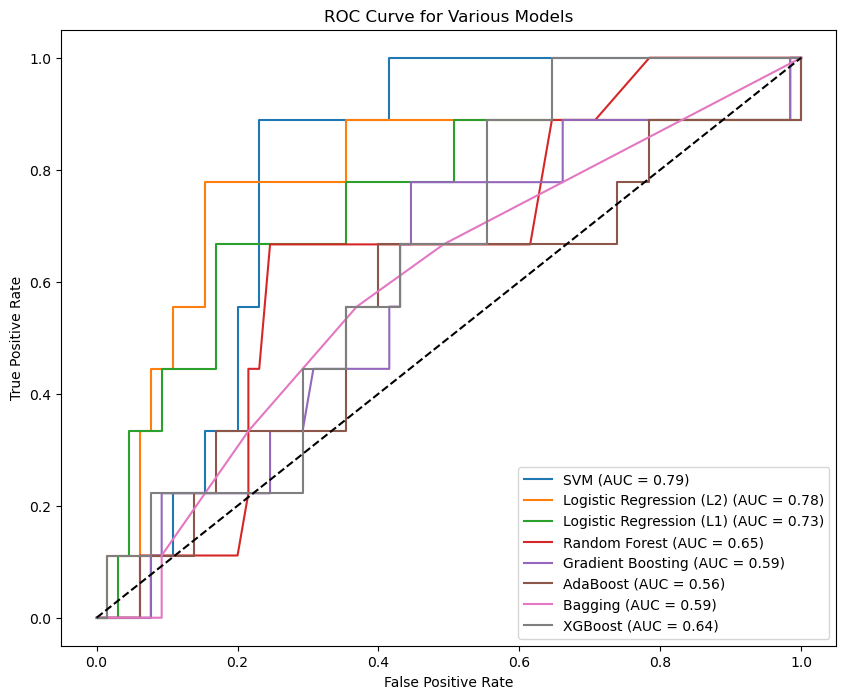

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

X = df.drop(columns=['Target'])
y = df['Target']

imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.35, random_state=432)

models = {
    "SVM": svm.SVC(probability=True),
    "Logistic Regression (L2)": LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000),
    "Logistic Regression (L1)": LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

feature_importances = {}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)

    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = model.feature_importances_

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    ks_stat = max(tpr - fpr)  # KS Statistic
    gini_coefficient = 2 * roc_auc_score(y_test, y_prob) - 1  # Gini Coefficient

    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"{name} Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n")
    print(f"{name} ROC AUC: {roc_auc_score(y_test, y_prob):.2f}")
    print(f"{name} Kolmogorov-Smirnov (KS): {ks_stat:.2f}")
    print(f"{name} Gini Coefficient: {gini_coefficient:.2f}\n")
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Various Models')
plt.legend()
plt.show()

## Stepwise and 1 to 5 feature selection 

Running RFE for Logistic Regression...
Selected Features for Logistic Regression: ['end_date', 'com_area', 'com_msprice', 'flat_height', 'Коэффициент оборачиваемости запасов', 'ROE', 'Коэффициент чистой прибыли']
Logistic Regression Accuracy: 0.84
Logistic Regression Confusion Matrix:
[[61  4]
 [ 8  1]]

Logistic Regression ROC AUC: 0.75
Logistic Regression Kolmogorov-Smirnov (KS): 0.56
Logistic Regression Gini Coefficient: 0.50

Running RFE for Random Forest...
Selected Features for Random Forest: ['flat_msprice', 'flat_mscost', 'Себестоимость', 'Операционная прибыль', 'Итоговая прибыль (убыток)', 'Коэффициент оборачиваемости запасов', 'Коэффициент финансовой независимости']
Random Forest Accuracy: 0.86
Random Forest Confusion Matrix:
[[63  2]
 [ 8  1]]

Random Forest ROC AUC: 0.64
Random Forest Kolmogorov-Smirnov (KS): 0.37
Random Forest Gini Coefficient: 0.28

Running RFE for Gradient Boosting...
Selected Features for Gradient Boosting: ['builder_id', 'com_msprice', 'share_cost', 'd

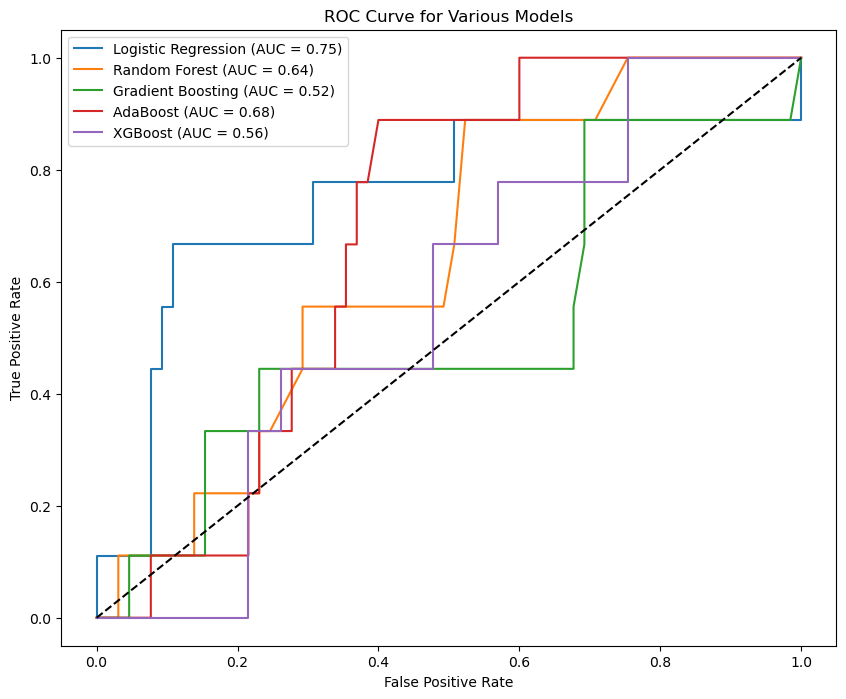

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

X = df.drop(columns=['Target'])
y = df['Target']

imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.35, random_state=432)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs'),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"Running RFE for {name}...")

    try:
        # RFE
        rfe_selector = RFE(estimator=model, n_features_to_select = 7)
        X_train_rfe = rfe_selector.fit_transform(X_train, y_train)
        X_test_rfe = rfe_selector.transform(X_test)

        selected_features = X.columns[rfe_selector.support_].tolist()
        print(f"Selected Features for {name}: {selected_features}")

        model.fit(X_train_rfe, y_train)

        y_pred = model.predict(X_test_rfe)
        y_prob = model.predict_proba(X_test_rfe)[:, 1] if hasattr(model, 'predict_proba') else y_pred

        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        ks_stat = max(tpr - fpr)  
        gini_coefficient = 2 * roc_auc_score(y_test, y_prob) - 1  

        print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.2f}")
        print(f"{name} Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n")
        print(f"{name} ROC AUC: {roc_auc_score(y_test, y_prob):.2f}")
        print(f"{name} Kolmogorov-Smirnov (KS): {ks_stat:.2f}")
        print(f"{name} Gini Coefficient: {gini_coefficient:.2f}\n")

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

    except Exception as e:
        print(f"Error with {name}: {e}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Various Models')
plt.legend()
plt.show()

## Target 2

In [10]:
df = pd.read_excel('fin_data_of_proj.xlsx')
df

,gara_id,application_name,author_id,builder_id,contractor_id,designer_id,engine_id,manager_id,status,decision_date,...,Коэффициент долговой нагрузки,Коэффициент долг на капитал,Коэффициент покрытия процентов,Покрытие долга,Target,life_cycle,today,real_life_cycle,percent_of_life_cycle,Target 2
0,729352,Заявка на гарантирование - 335,5.400012e+08,960340000376,9.603400e+11,0.000000e+00,2.210400e+11,1.904400e+11,NaN,NaT,...,1.0,0.060174,5.733126,3.488284,0,395,2024-11-01,729,1.845570,0
1,790750,Заявка на гарантирование - 334,4.044001e+10,960340000376,9.603400e+11,0.000000e+00,2.210400e+11,1.904400e+11,NaN,NaT,...,1.0,0.060174,5.733126,3.488284,0,639,2024-11-01,729,1.140845,0
2,845821,Заявка на гарантирование - 407,8.034001e+10,60340004172,6.034000e+10,0.000000e+00,1.304400e+11,2.109400e+11,NaN,NaT,...,1.0,0.929396,20.794199,0.550207,0,274,2024-11-01,508,1.854015,0
3,781580,Заявка на гарантирование - 379,5.114001e+10,981040003722,9.810400e+11,0.000000e+00,7.054001e+10,2.109400e+11,NaN,NaT,...,1.0,0.020449,1331.828571,5.548625,0,426,2024-11-01,742,1.741784,0
4,746713,Заявка на гарантирование - 373,9.207400e+11,80440009616,8.044001e+10,0.000000e+00,2.208400e+11,2.202400e+11,NaN,NaT,...,1.0,0.000000,inf,inf,0,275,2024-11-01,575,2.090909,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,91,NaN,1.054000e+10,110540015593,9.706400e+11,NaN,1.304400e+11,1.703400e+11,Завершенный,2020-02-14,...,1.0,0.138312,inf,7.945981,1,453,2024-11-01,1813,4.002208,0
218,84,NaN,NaN,50440002386,5.044000e+10,NaN,3.114000e+10,1.706400e+11,Завершенный,2021-06-28,...,1.0,0.024880,inf,1.897679,0,376,2024-11-01,1363,3.625000,0
219,111,NaN,6.074000e+10,60740002715,6.074000e+10,NaN,5.054001e+10,2.102400e+11,Завершенный,2021-04-27,...,1.0,NaN,inf,NaN,0,250,2024-11-01,1337,5.348000,0
220,2,NaN,3.114000e+10,111140016064,2.064000e+10,NaN,1.402400e+11,2.106400e+11,Завершенный,2022-02-24,...,1.0,0.000000,1.039538,inf,0,141,2024-11-01,1082,7.673759,0


In [193]:
# Unfin_cost and Season of every year

def get_season(date):
    month = date.month if pd.notnull(date) else None
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return None

df['season'] = df['dpg_date'].apply(get_season)
df['unfin_coff'] = df['unfin_cost']/df['cost_plan']

In [194]:
# Inflaction of every year 8%

annual_inflation_rate = 0.08
inflation_reference_date = datetime(2024, 11, 1)


df['dpg_date'] = pd.to_datetime(df['dpg_date'], errors='coerce')

financial_columns = [
    'cost_plan', 'flat_msprice', 'build_mscost', 'flat_mscost', 'com_msprice', 'park_price',
    'self_cost', 'unfin_cost', 'share_cost', 'warr_cost', 'comm_cost', 'cost_official',
    'Итого краткосрочные активы', 'Итого краткосрочных обязательств', 'Денежные средства',
    'Краткосрочная дебиторская задолженность', 'Запасы', 'Себестоимость', 'Доход от реализации',
    'Итого активы', 'Итого капитал', 'Итого пассивы', 'Краткосрочная кредиторская задолженность',
    'Операционная прибыль', 'Долгосрочные финансовые обязательства', 'Краткосрочные финансовые обязательства',
    'Итоговая прибыль (убыток)', 'Расходы на финансирование'
]

df['years_since_dpg'] = (inflation_reference_date - df['dpg_date']).dt.days / 365.25
df['inflation_factor'] = (1 + annual_inflation_rate) ** df['years_since_dpg']

for col in financial_columns:
    if col in df.columns:
        df[col] = df[col] * df['inflation_factor']

df.drop(columns=['years_since_dpg', 'inflation_factor'], inplace=True)


In [195]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df = df[:-11]
df = df.drop(columns=['application_name', 'author_id', 'engine_id', 'manager_id', 'status', 'decision_date',
                          'region_name', 'build_mscost', 'dpg_num_text', 'prolongation', 'update_date', 'state_id',
                          'create_date', 'annul_date', 'state_name', 'дата фин данных', 'life_cycle', 'today',
                          'real_life_cycle'])
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.drop('Target', axis = 1)
df = df.dropna(axis=1, how='all')

non_numeric_cols = df.select_dtypes(include=['object', 'datetime', 'timedelta']).columns

label_encoder = LabelEncoder()
for col in non_numeric_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

In [196]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

SVM Accuracy: 0.95
SVM Confusion Matrix:
[[21  0]
 [ 1  0]]

SVM ROC AUC: 0.52

LogisticRegression Accuracy: 0.95
LogisticRegression Confusion Matrix:
[[21  0]
 [ 1  0]]

LogisticRegression ROC AUC: 0.81

Random Forest Accuracy: 0.95
Random Forest Confusion Matrix:
[[21  0]
 [ 1  0]]

Random Forest ROC AUC: 1.00

Gradient Boosting Accuracy: 0.95
Gradient Boosting Confusion Matrix:
[[21  0]
 [ 1  0]]

Gradient Boosting ROC AUC: 1.00

AdaBoost Accuracy: 0.95
AdaBoost Confusion Matrix:
[[21  0]
 [ 1  0]]

AdaBoost ROC AUC: 1.00



C:\Users\Norynbayev\AppData\Local\miniconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Bagging Accuracy: 0.91
Bagging Confusion Matrix:
[[20  1]
 [ 1  0]]

Bagging ROC AUC: 0.83

XGBoost Accuracy: 0.95
XGBoost Confusion Matrix:
[[21  0]
 [ 1  0]]

XGBoost ROC AUC: 0.95



C:\Users\Norynbayev\AppData\Local\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:19:54] WARNING: D:\bld\xgboost-split_1732150467793\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


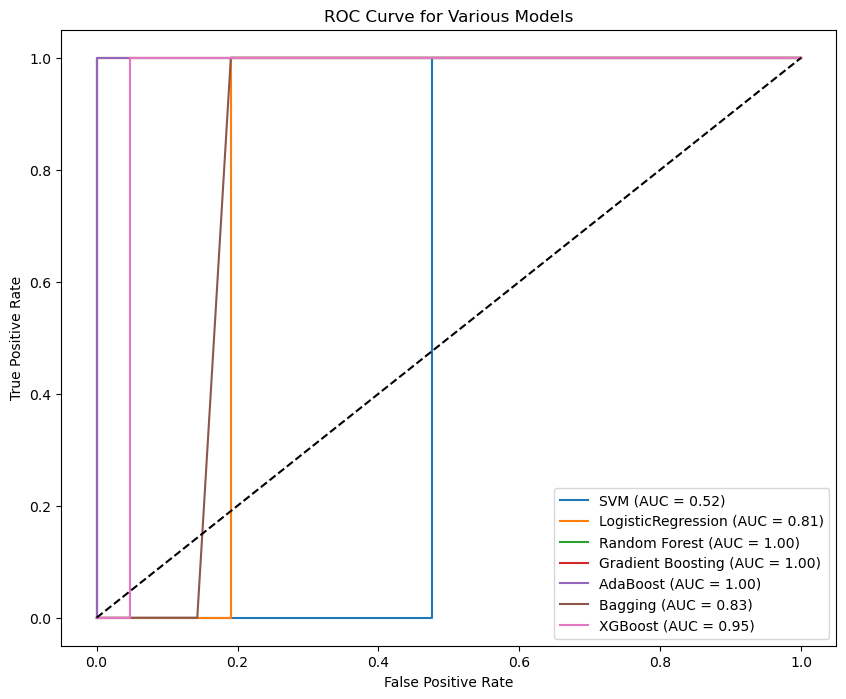

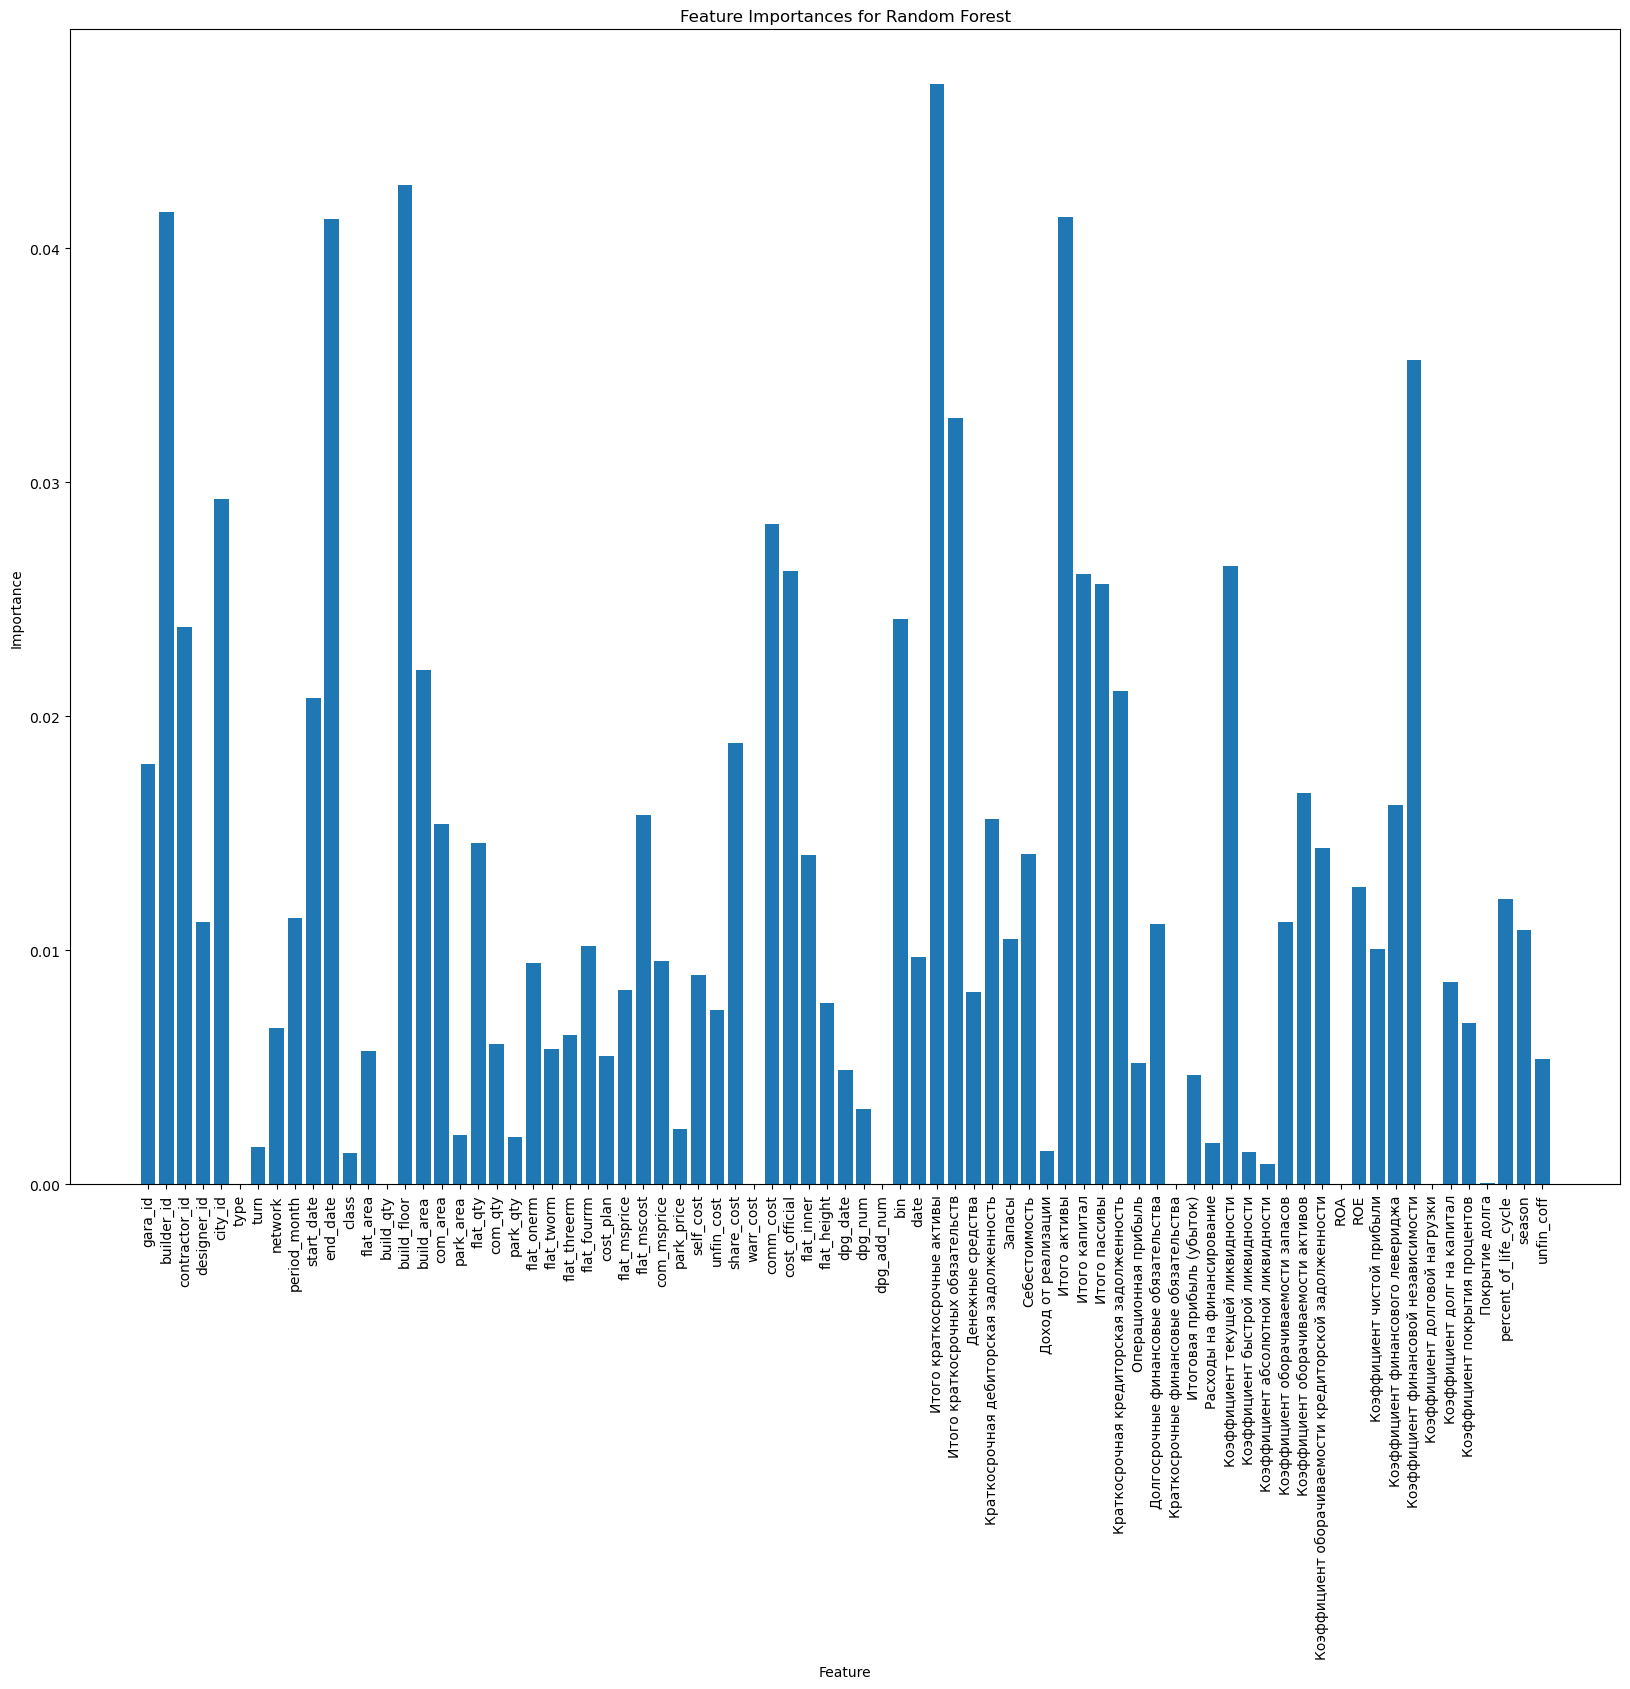

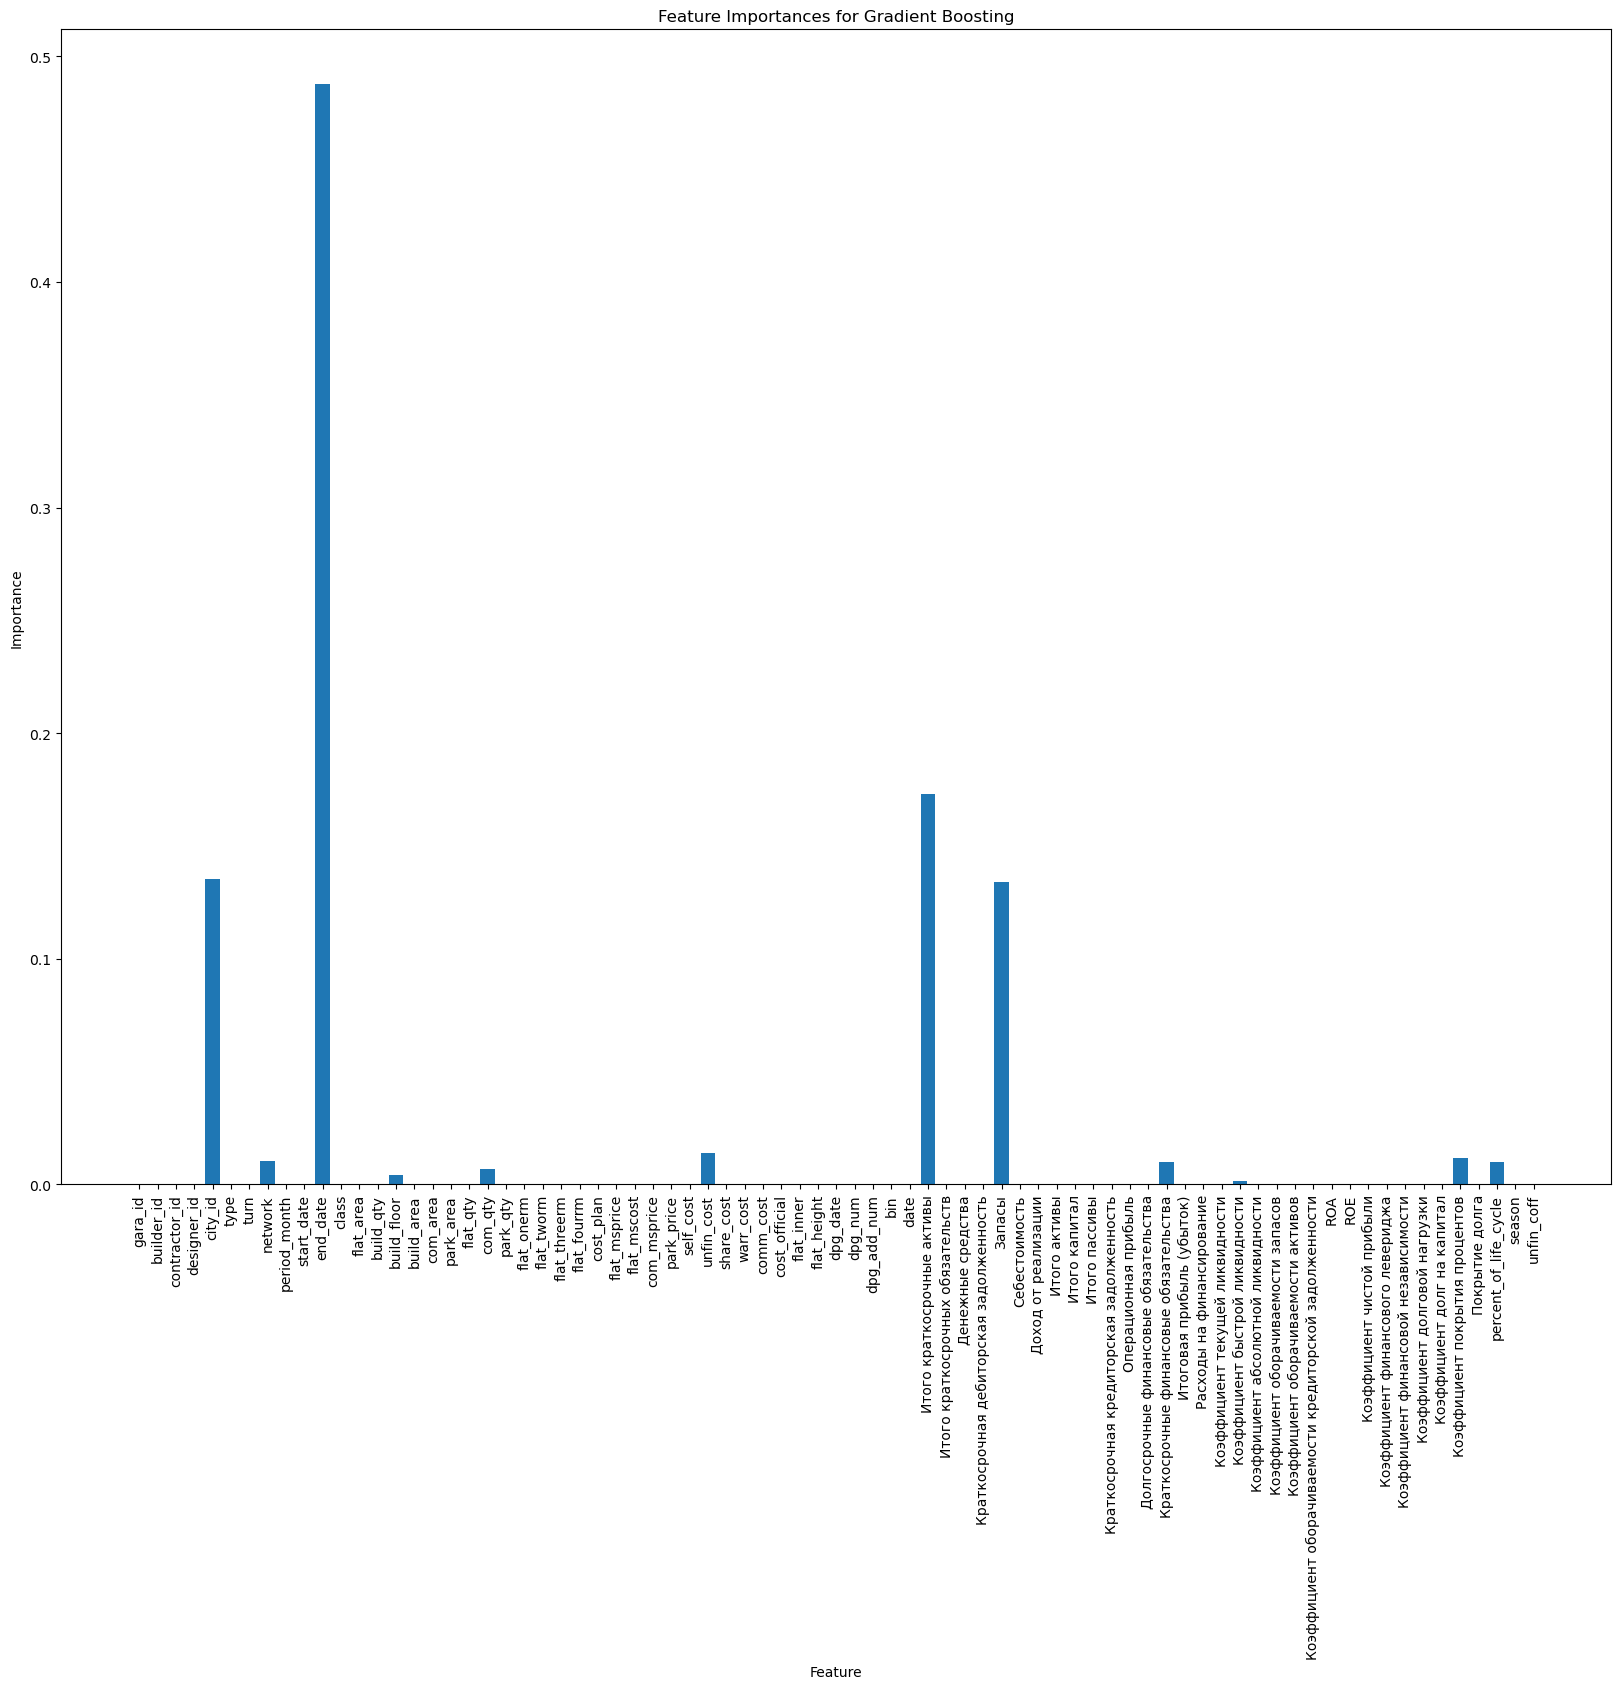

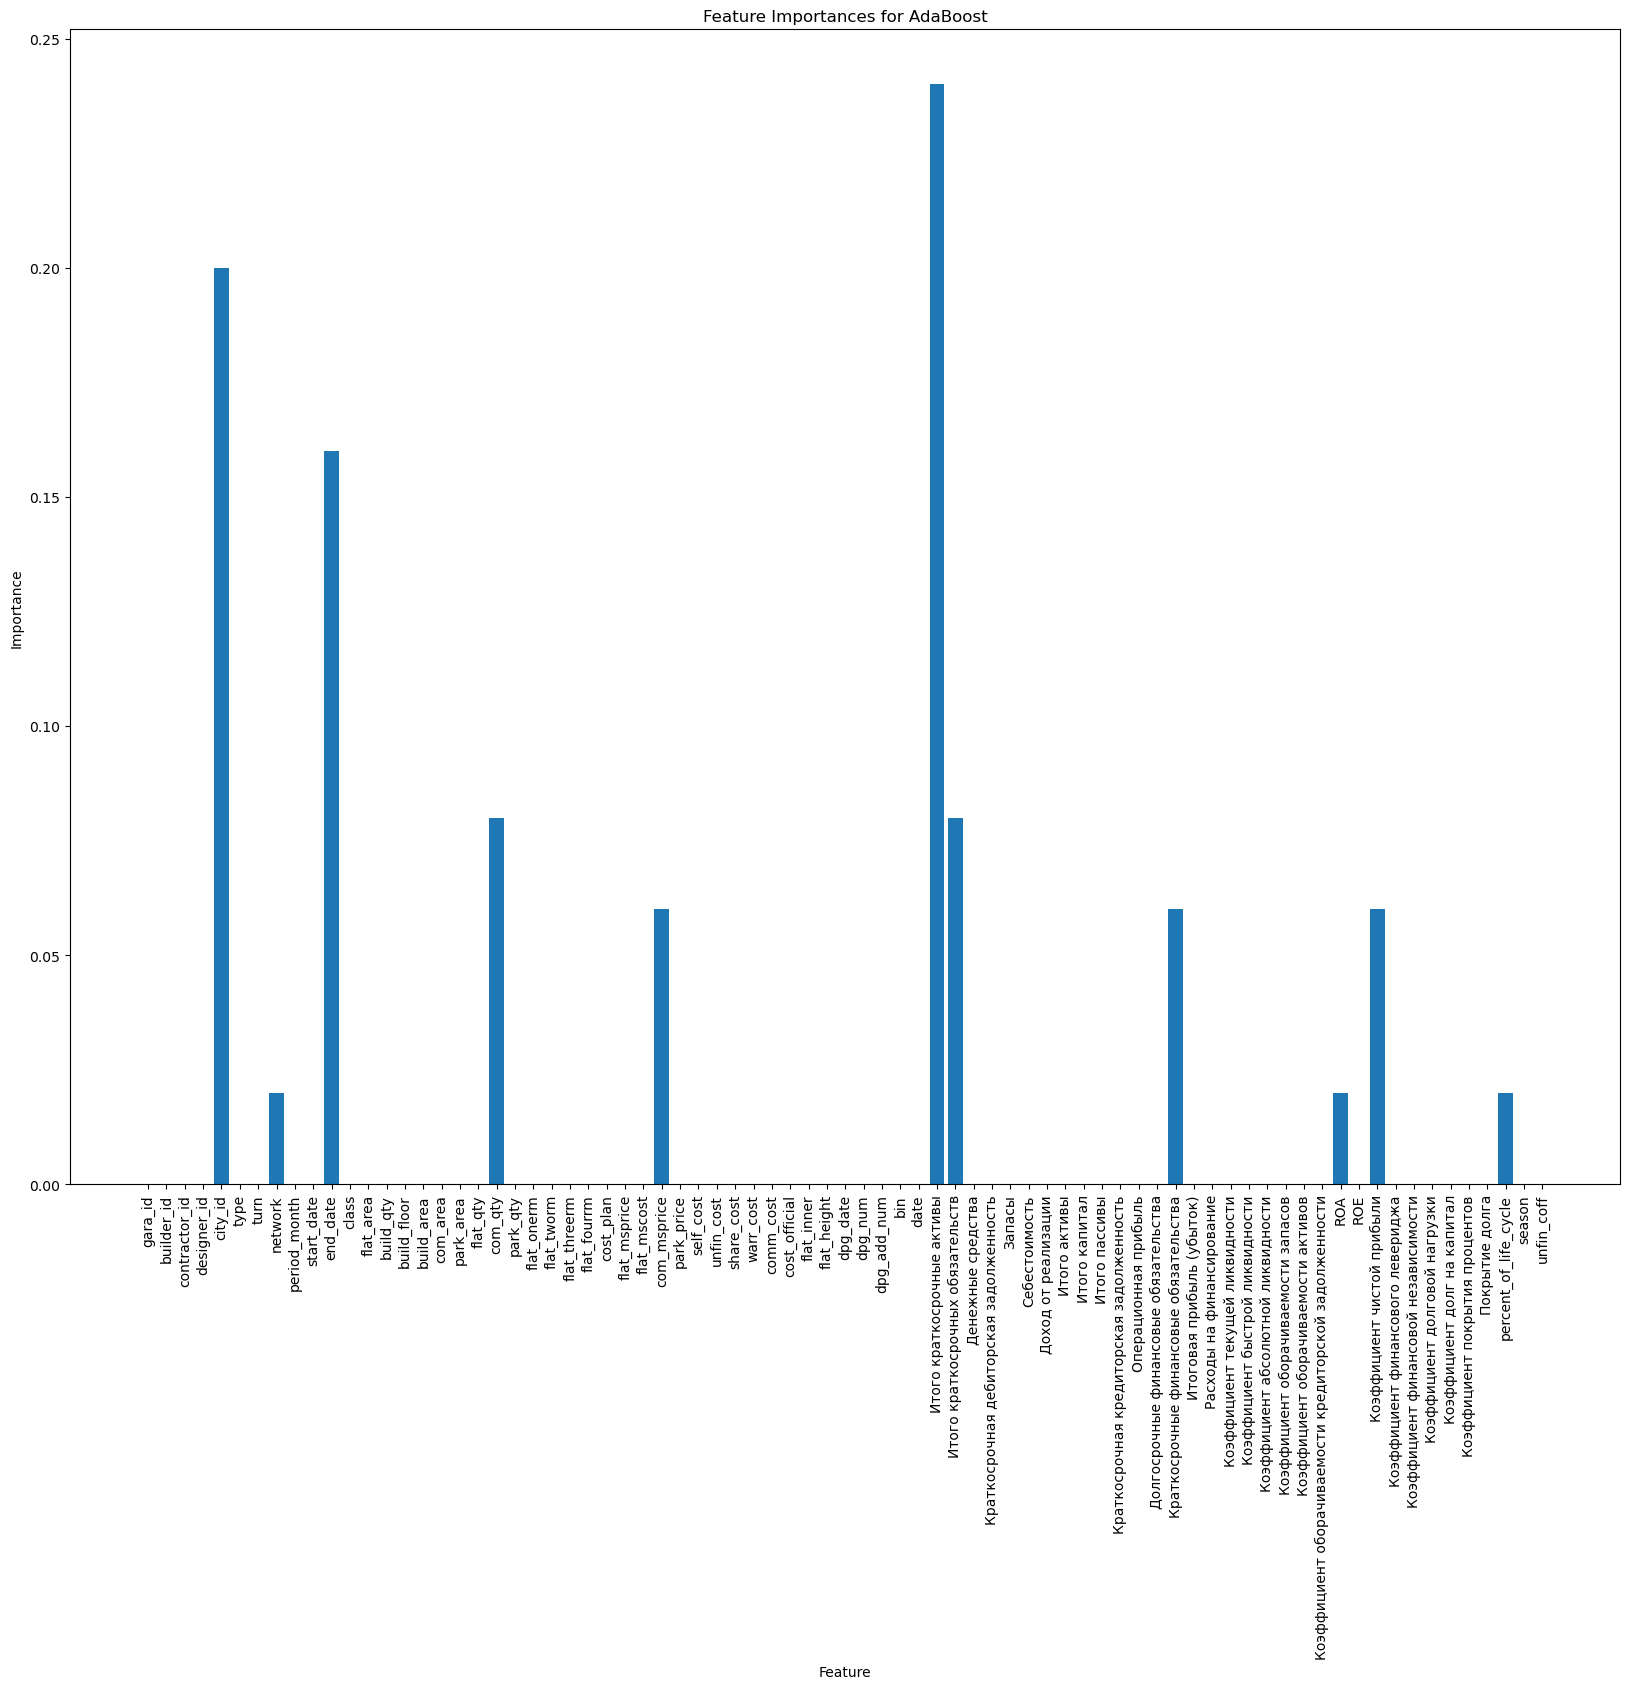

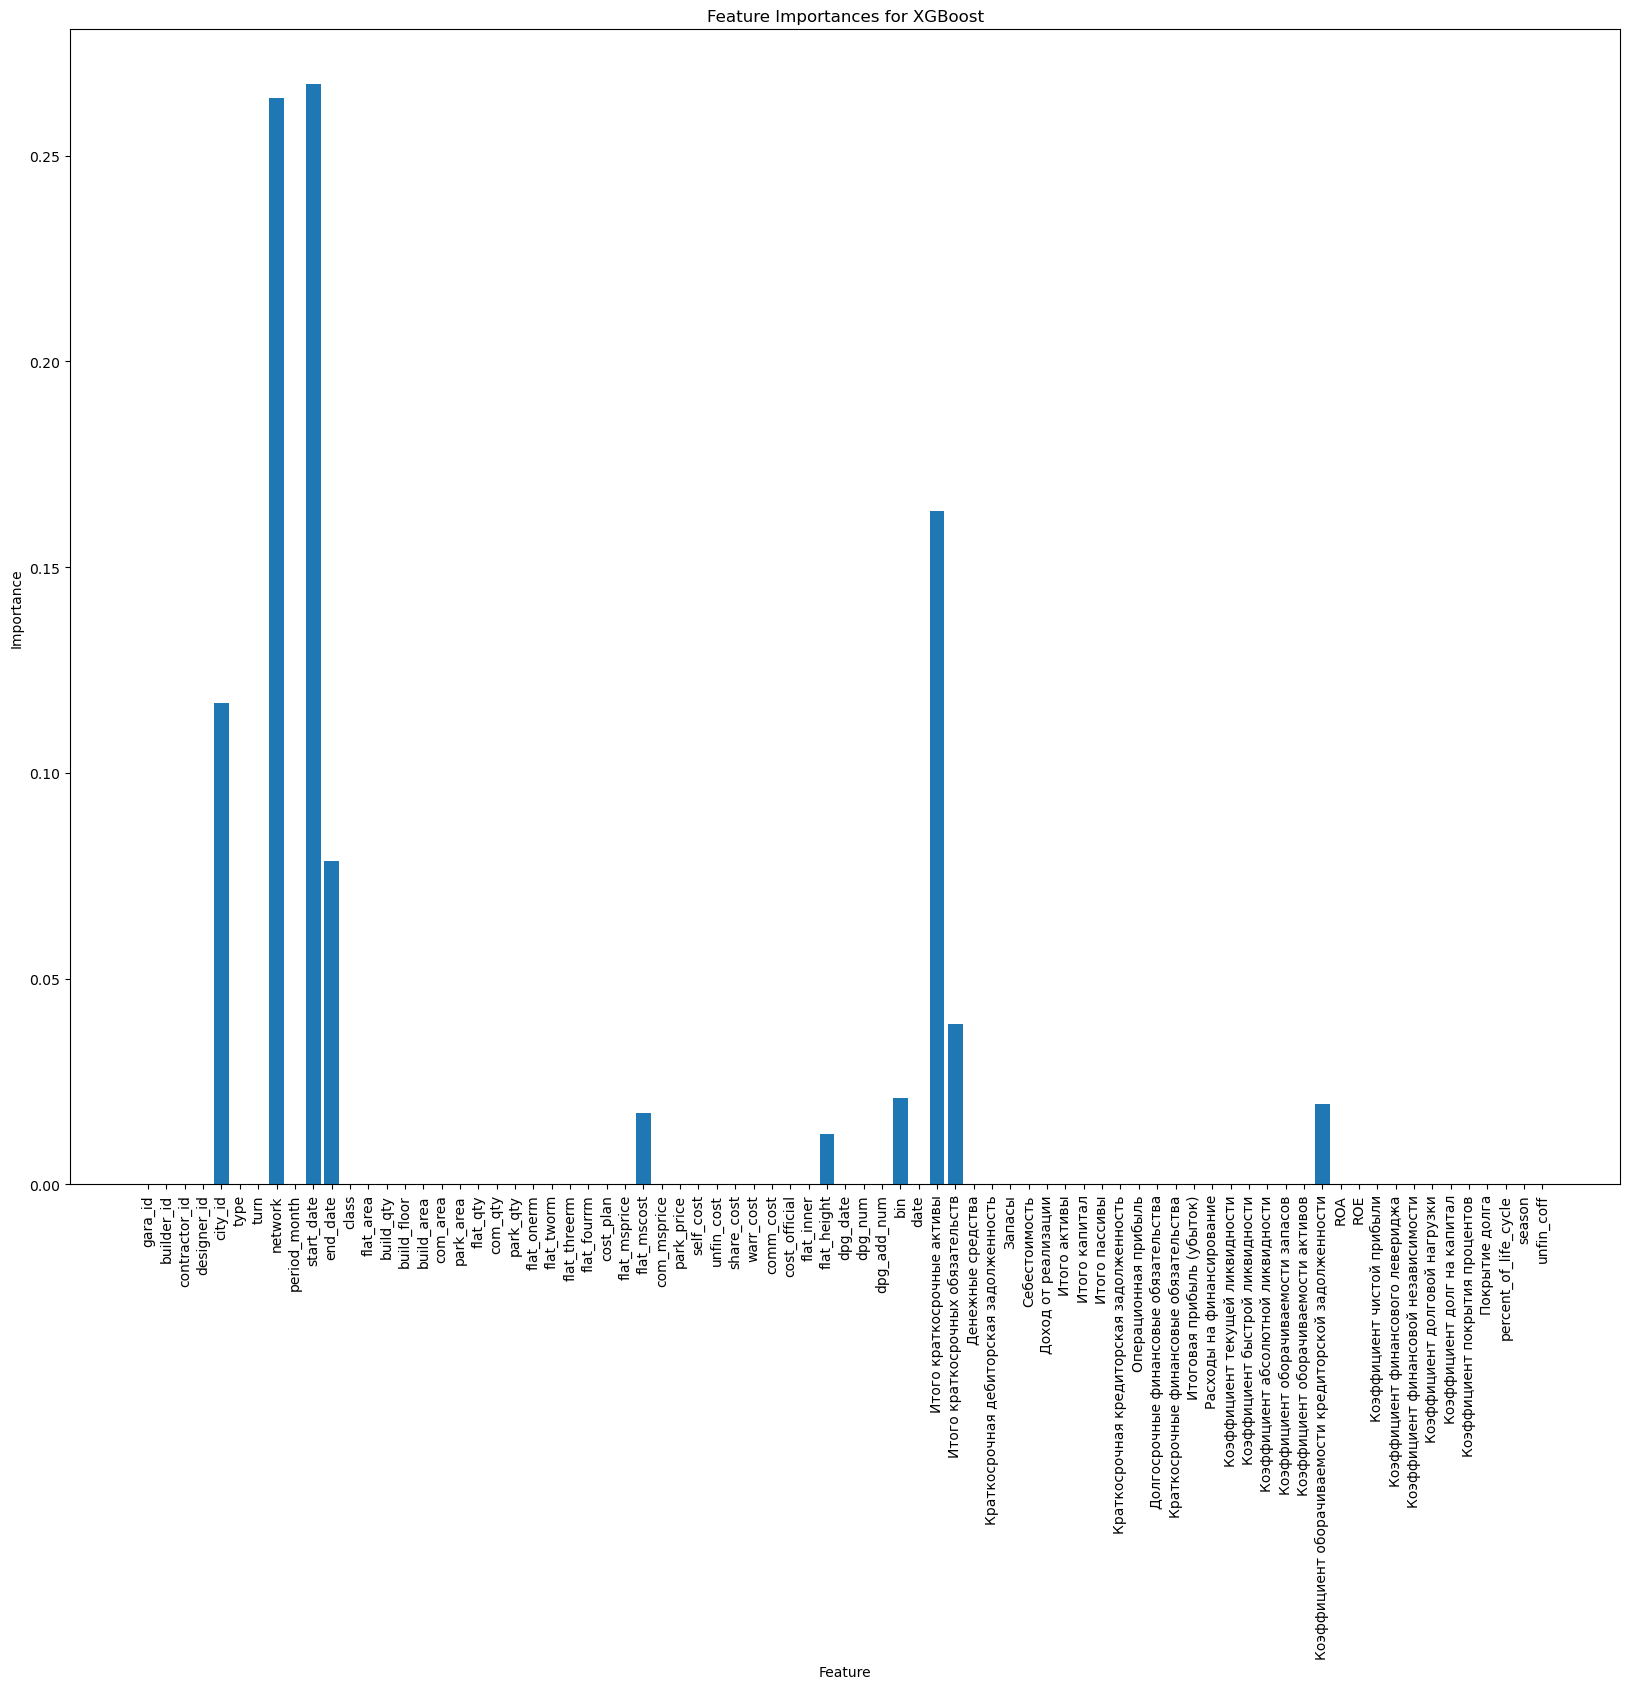

In [197]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

X = df.drop(columns=['Target 2'])
y = df['Target 2']

imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=434)

models = {
    "SVM": svm.SVC(probability=True),
    "LogisticRegression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

feature_importances = {}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)

    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = model.feature_importances_

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"{name} Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n")
    print(f"{name} ROC AUC: {roc_auc_score(y_test, y_prob):.2f}\n")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Various Models')
plt.legend()
plt.show()

for name, importance in feature_importances.items():
    plt.figure(figsize=(20, 15))
    plt.bar(range(len(importance)), importance)
    plt.title(f"Feature Importances for {name}")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.xticks(range(len(importance)), X.columns, rotation=90)
    plt.show()

In [198]:
df

,gara_id,builder_id,contractor_id,designer_id,city_id,type,turn,network,period_month,start_date,...,Коэффициент финансового левериджа,Коэффициент финансовой независимости,Коэффициент долговой нагрузки,Коэффициент долг на капитал,Коэффициент покрытия процентов,Покрытие долга,percent_of_life_cycle,Target 2,season,unfin_coff
0,729352.0,9.603400e+11,9.603400e+11,0.0,18178.0,1.0,37.0,59.0,13.0,146.0,...,1.163885,0.859191,1.0,0.060174,5.733126,3.488284,1.845570,0.0,2.0,14.881747
1,790750.0,9.603400e+11,9.603400e+11,0.0,18178.0,1.0,40.0,60.0,21.0,146.0,...,1.163885,0.859191,1.0,0.060174,5.733126,3.488284,1.140845,0.0,2.0,0.143970
2,845821.0,6.034000e+10,6.034000e+10,0.0,18277.0,1.0,40.0,61.0,9.0,165.0,...,6.964214,0.143591,1.0,0.929396,20.794199,0.550207,1.854015,0.0,0.0,0.109875
3,781580.0,9.810400e+11,9.810400e+11,0.0,18267.0,1.0,40.0,59.0,14.0,144.0,...,3.248147,0.307868,1.0,0.020449,1331.828571,5.548625,1.741784,0.0,2.0,0.150448
4,746713.0,8.044001e+10,8.044001e+10,0.0,18194.0,1.0,33.0,60.0,10.0,160.0,...,1.252455,0.798432,1.0,0.000000,1.522332,0.155298,2.090909,0.0,2.0,0.210085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,1152403.0,1.312400e+11,1.312400e+11,0.0,18178.0,1.0,40.0,60.0,12.0,181.0,...,2.829602,0.353407,1.0,0.000000,26.373242,0.155298,0.673973,0.0,1.0,0.145033
207,1130533.0,5.064001e+10,5.064001e+10,0.0,18277.0,1.0,40.0,60.0,10.0,178.0,...,2.561520,0.390393,1.0,0.331792,1.522332,0.823126,0.921311,0.0,1.0,0.104933
208,1124311.0,1.708400e+11,1.708400e+11,0.0,18194.0,1.0,42.0,60.0,23.0,177.0,...,6.597274,0.151578,1.0,5.479264,1.522332,-0.039945,0.462197,0.0,1.0,0.000000
209,1159397.0,3.104000e+10,3.104000e+10,0.0,18274.0,1.0,40.0,59.0,10.0,184.0,...,1.807297,0.553313,1.0,0.000000,1.522332,0.155298,0.601974,0.0,1.0,0.000000
